# LASPATED Replication


Interactive notebook to generate discretizations, compile and run the C++ code and generate the replication results.

## How to use

1. Run the setup cell.
2. Generate the discretizations.
3. Compile the C++ code.
4. Run the C++ experiments.
5. Generate the figures and tables.

If you are using Gurobi, set `USE_GUROBI = True` before compiling.


In [7]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

REPO_DIR = Path.cwd().resolve().parent
REPLICATION_DIR = REPO_DIR / 'Replication'
os.chdir(REPLICATION_DIR)
sys.path.insert(0, str(REPLICATION_DIR))

spec = importlib.util.spec_from_file_location('replication_script', REPLICATION_DIR / 'replication_script.py')
rs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rs)

print('Repo:', REPO_DIR)
print('Working dir:', Path.cwd())

Repo: /home/victor/Downloads/Projetos/Laspated_Replication
Working dir: /home/victor/Downloads/Projetos/Laspated_Replication/Replication


In [8]:
USE_GUROBI = False
GUROBI_VER = "110"
RUN_CPP_EXPERIMENTS = True
RUN_PLOTS = True

(REPLICATION_DIR / 'replication_results' / 'plots').mkdir(parents=True, exist_ok=True)
(REPLICATION_DIR / 'replication_results' / 'tables').mkdir(parents=True, exist_ok=True)
print('Output directories ready.')

Output directories ready.


Wrote discretization files for disc rect. 76 regions
Wrote discretization files for disc hex. 226 regions
Wrote discretization files for disc district. 160 regions


[76, 160, 226]

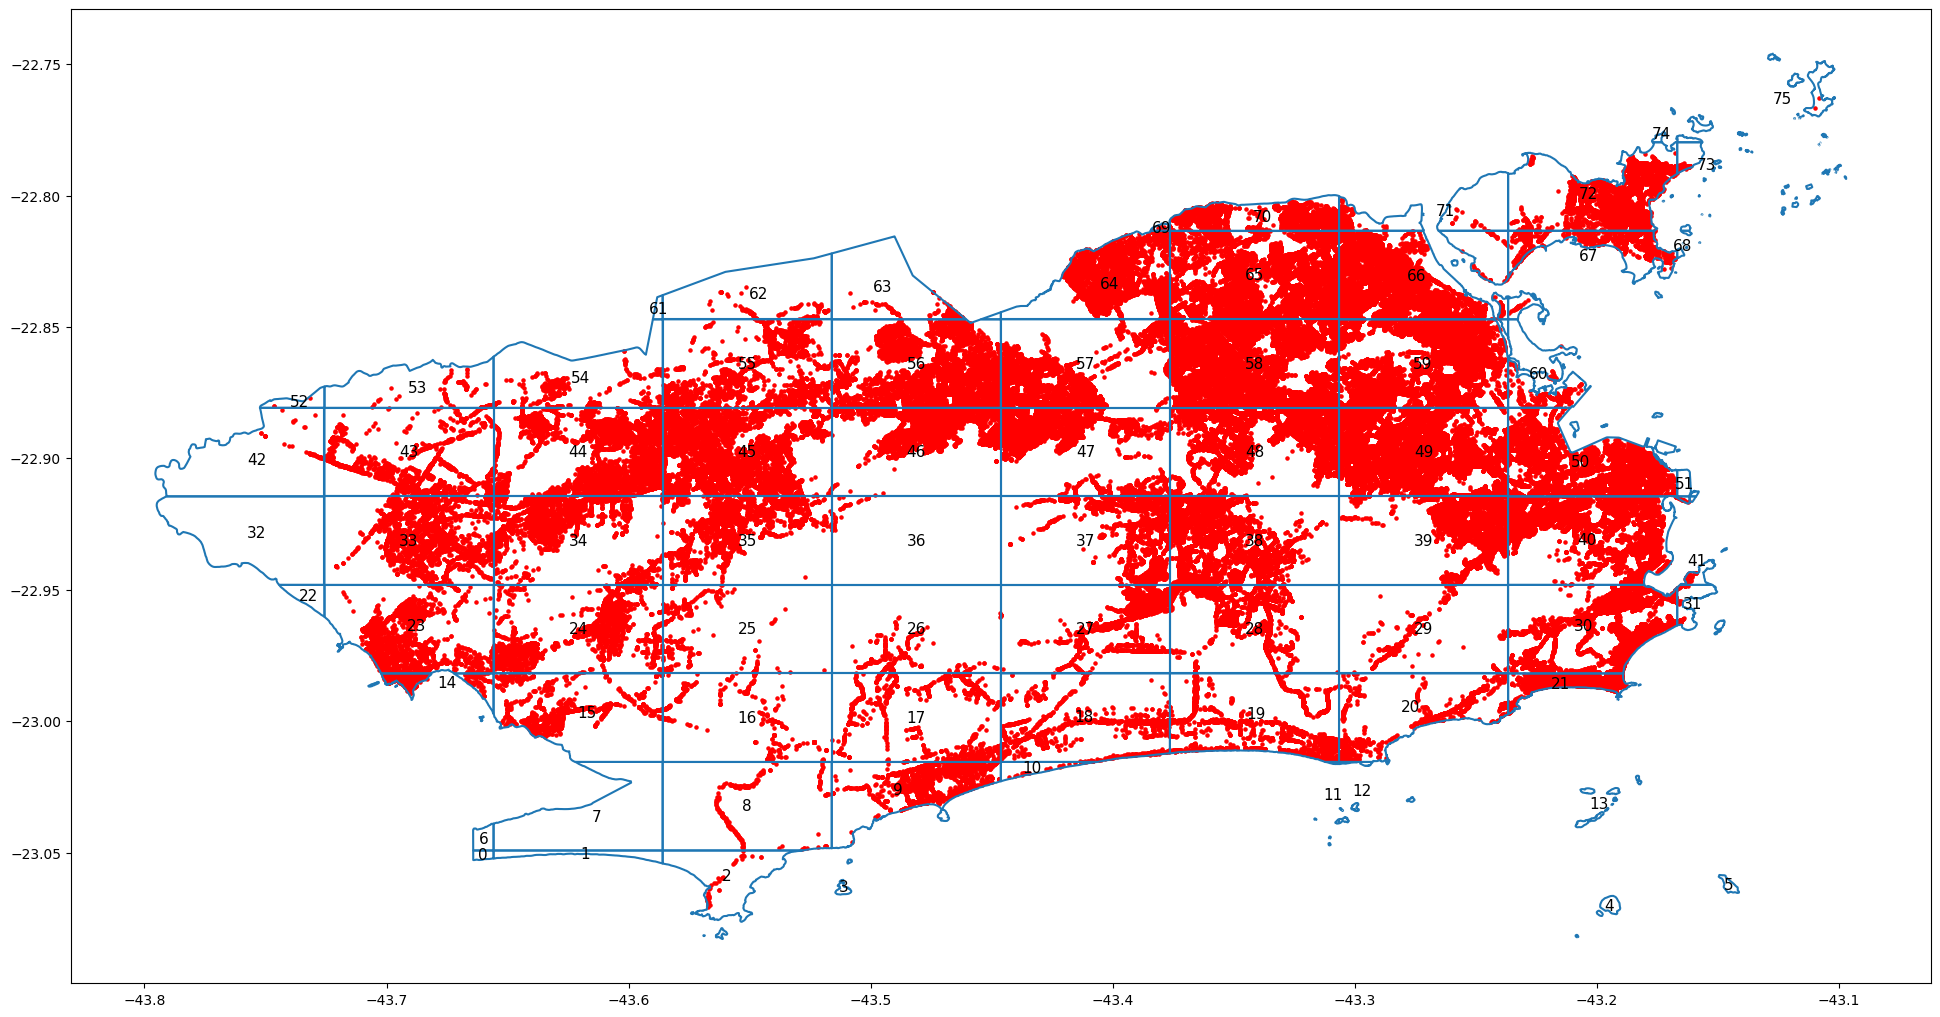

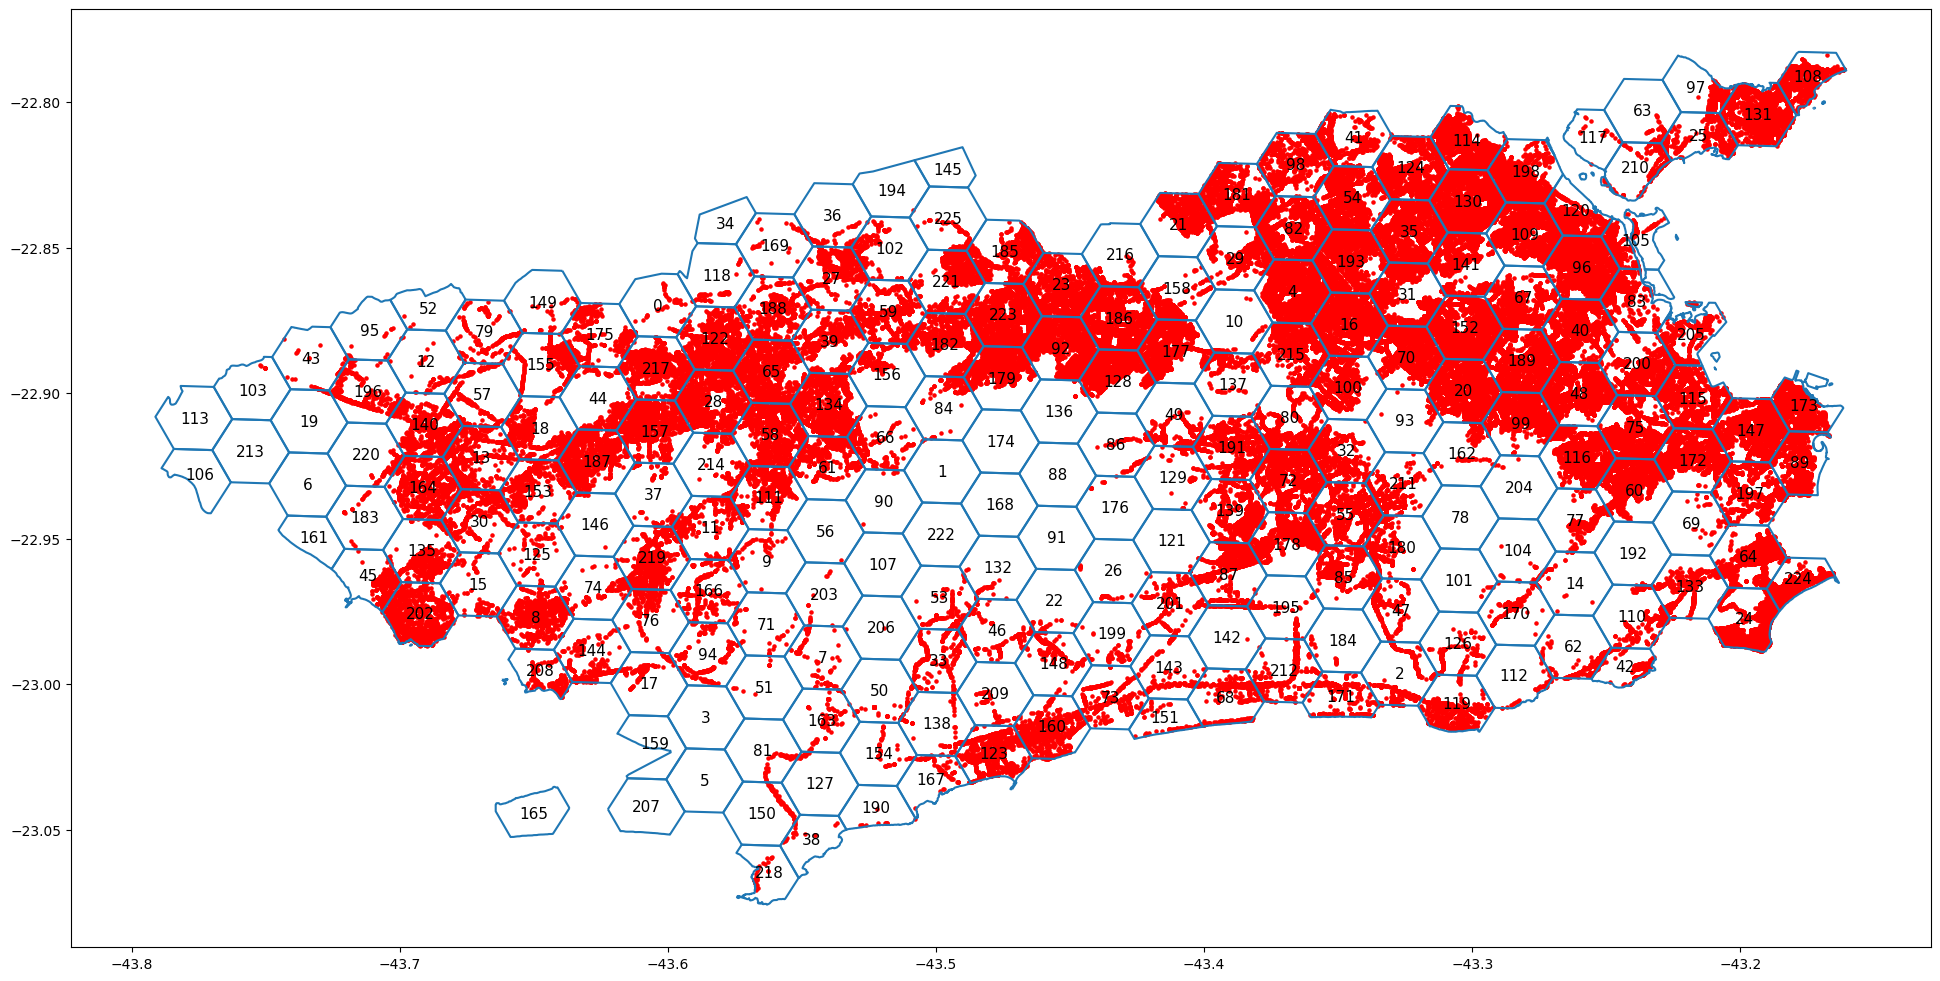

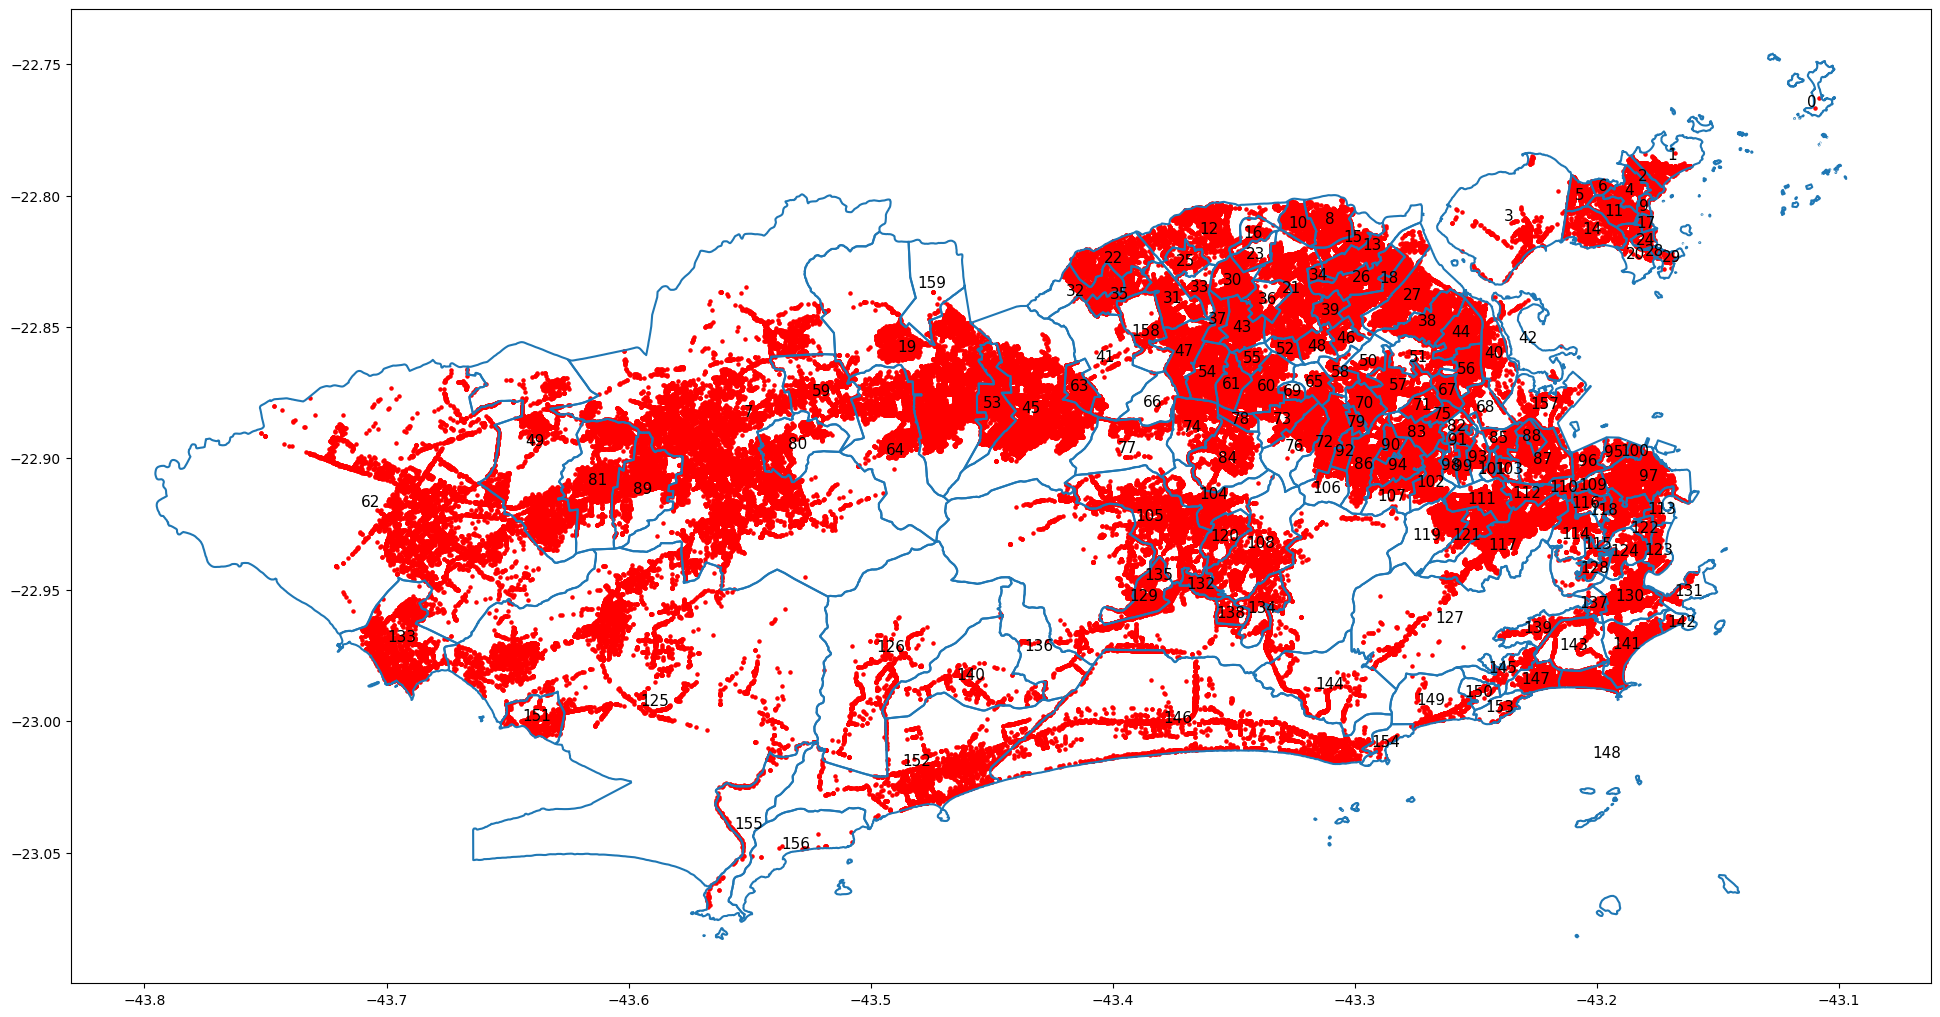

In [9]:
# Generate the discretizations used by the replication
rs.generate_discretizations()
sorted(rs.DISCS.keys())

In [10]:
# Compile the C++ code
model_cmd = ['make', '-C', str(REPO_DIR / 'Model_Calibration' / 'Cpp')]
replication_cmd = ['make', '-C', 'cpp_tests']
if USE_GUROBI:
    model_cmd += ['USE_GUROBI=1', f'GUROBI_VER={GUROBI_VER}']
    replication_cmd += ['USE_GUROBI=1', f'GUROBI_VER={GUROBI_VER}']
else:
    model_cmd += ['USE_GUROBI=0']
    replication_cmd += ['USE_GUROBI=0']

print('Running:', ' '.join(model_cmd))
subprocess.run(model_cmd, check=True)
print('Running:', ' '.join(replication_cmd))
subprocess.run(replication_cmd, check=True)
print('C++ build finished.')


Running: make -C /home/victor/Downloads/Projetos/Laspated_Replication/Model_Calibration/Cpp USE_GUROBI=0
make: Entrando no diretório '/home/victor/Downloads/Projetos/Laspated_Replication/Model_Calibration/Cpp'
OS detected: Linux
Architecture detected: x86_64
CFLAGS: -m64
g++ -o laspated laspated.cpp -std=c++14 -Wfatal-errors -Wno-ignored-attributes   -m64 -DUSE_GUROBI=0   -I.  -lboost_program_options -O3
make: Saindo do diretório '/home/victor/Downloads/Projetos/Laspated_Replication/Model_Calibration/Cpp'
Running: make -C cpp_tests USE_GUROBI=0
make: Entrando no diretório '/home/victor/Downloads/Projetos/Laspated_Replication/Replication/cpp_tests'
OS detected: Linux
Architecture detected: x86_64
CFLAGS: -m64
g++ -o laspated main.cpp -std=c++14 -Wfatal-errors -Wno-ignored-attributes   -m64 -DUSE_GUROBI=0  -I../../Model_Calibration/Cpp  -lboost_program_options -I. -O3
make: Saindo do diretório '/home/victor/Downloads/Projetos/Laspated_Replication/Replication/cpp_tests'
C++ build finished

In [11]:
# Run the C++ experiments
if RUN_CPP_EXPERIMENTS:
    rs.run_cpp_experiments()
else:
    print('Skipping C++ experiments.')

Running test1: G = 2, weeks = 1, neighbors = 0, model_type = 0, Cross validation = 0
Finished regularized PG with k = 100, f = -230203.713791, improv_final = 0.000000, avg_improv = 0.001350
Finished regularized PG with k = 100, f = -228866.734508, improv_final = 0.000000, avg_improv = 0.014144
Finished regularized PG with k = 100, f = -228857.628392, improv_final = 0.000000, avg_improv = 0.000000
Finished regularized PG with k = 100, f = -228854.433753, improv_final = 0.000000, avg_improv = 0.000000
Finished regularized PG with k = 100, f = -228852.935650, improv_final = 0.000000, avg_improv = 0.000000
Finished regularized PG with k = 100, f = -228852.091091, improv_final = 0.000000, avg_improv = 0.000000
Finished regularized PG with k = 100, f = -228851.555025, improv_final = 0.000000, avg_improv = 0.000000
Finished regularized PG with k = 100, f = -228851.160713, improv_final = 0.000000, avg_improv = 0.000000
Finished regularized PG with k = 100, f = -228850.874921, improv_final = 0.

In [12]:
# Generate figures and tables
if RUN_PLOTS:
    rs.plot_results()
else:
    print('Skipping plots.')

Plot of err by weights for model 2 with 1 weeks saved at replication_results/plots/plot_err_by_weight_m2_obs1.pdf
Plot of err by weights for model 1 with 1 weeks saved at replication_results/plots/plot_err_by_weight_m1_obs1.pdf
Plot of err by weights for model 2 with 10 weeks saved at replication_results/plots/plot_err_by_weight_m2_obs10.pdf
Plot of err by weights for model 1 with 10 weeks saved at replication_results/plots/plot_err_by_weight_m1_obs10.pdf
Plot of err by weights for model 2 with 50 weeks saved at replication_results/plots/plot_err_by_weight_m2_obs50.pdf
Plot of err by weights for model 1 with 50 weeks saved at replication_results/plots/plot_err_by_weight_m1_obs50.pdf
Plot of err by weights for model 2 with 500 weeks saved at replication_results/plots/plot_err_by_weight_m2_obs500.pdf
Plot of err by weights for model 1 with 500 weeks saved at replication_results/plots/plot_err_by_weight_m1_obs500.pdf
No covariates experiments table saved at replication_results/tables/tabl

In [13]:
# Inspect generated outputs
plots = sorted((REPLICATION_DIR / 'replication_results' / 'plots').glob('*'))
tables = sorted((REPLICATION_DIR / 'replication_results' / 'tables').glob('*'))
print('Plots:', len(plots))
for path in plots[:10]:
    print(' -', path.name)
print('Tables:', len(tables))
for path in tables:
    print(' -', path.name)

Plots: 34
 - art_rates_by_t_w10_r1.pdf
 - art_rates_by_t_w10_r6.pdf
 - art_rates_by_t_w1_r1.pdf
 - art_rates_by_t_w1_r6.pdf
 - heat_c0_r76.pdf
 - heat_c1_r76.pdf
 - heat_c2_r76.pdf
 - heat_total_r76_emp.pdf
 - heat_total_r76_m1.pdf
 - heat_total_r76_m2.pdf
Tables: 2
 - table_covariates_results.txt
 - table_no_covariates_results.txt
